# `Maranatha.jl` :: Filter and Rebuild Results

This notebook demonstrates how to remove selected resolution points
from a previously generated quadrature dataset and rebuild a filtered
result file for further analysis.

This workflow is useful when:

- certain low- or high-resolution points should be excluded
- you want to test the stability of the extrapolation fit
- some datapoints are considered unsuitable for a specific analysis
- you want to rebuild a cleaner dataset without rerunning the full computation

The overall workflow is:

1. Generate or locate a saved result file
2. Remove selected `nsamples` from the file
3. Load the filtered dataset
4. Inspect the remaining datapoints
5. Perform fitting and visualization again

## Initialize Julia environment

First we load the
**`Maranatha.jl`** package.

In [1]:
using Maranatha
using DoubleFloats

## Generate the original dataset

To demonstrate the filtering workflow, we first generate
a standard quadrature dataset using the TOML-based interface.

This step creates the saved JLD2 result file that will later
be modified by removing selected resolution points.

As in the earlier notebooks, the same dataset could also be
generated directly from Julia code instead of a TOML file.

In [2]:
toml_path = "../samples/sample_1d.toml"

toml_dir = dirname(toml_path)

run_result = run_Maranatha(toml_path)

[2026-03-21 20:03:38.992] run config: dim=1, rule=gauss_p4, boundary=LU_EXEX, err_method=refinement


(a = 0.0, b = 3.14159265358979323846264338327950588, nsamples = [2, 3, 4, 5, 6, 7, 8, 9], h = Double64[1.57079632679489661923132169163975294, 1.04719755119659774615421446109316863, 7.8539816339744830961566084581987647e-01, 6.28318530717958647692528676655902408e-01, 5.23598775598298873077107230546584313e-01, 4.487989505128276054946633404685004e-01, 3.92699081698724154807830422909938235e-01, 3.49065850398865915384738153697721848e-01], tuple_h = Any[1.57079632679489661923132169163975294, 1.04719755119659774615421446109316863, 7.8539816339744830961566084581987647e-01, 6.28318530717958647692528676655902408e-01, 5.23598775598298873077107230546584313e-01, 4.487989505128276054946633404685004e-01, 3.92699081698724154807830422909938235e-01, 3.49065850398865915384738153697721848e-01], avg = Double64[1.99999995439423081403808874398459154, 1.99999999830804213963690459797591622, 1.99999999983352198159742497454276978, 1.99999999997229121505423362875646540, 1.99999999999358363313801524748090606, 1.999

## Reconstruct the saved result filename

Next we define the metadata needed to identify the saved
quadrature result file.

These values must match the dataset that was generated above,
so that the correct JLD2 file can be located and modified.

In [3]:
ns = [2, 3, 4, 5, 6, 7, 8, 9]

save_path = joinpath(toml_dir, "jld2")

result_string = "sample_1d"
rule = :gauss_p4
boundary = :LU_EXEX

Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

"../samples/jld2/result_sample_1d_gauss_p4_LU_EXEX_N_2_3_4_5_6_7_8_9.jld2"

## Remove selected resolution points

The function `drop_nsamples_from_file` creates a new filtered
result file by removing specific resolution points from an
existing dataset.

In this example we remove the datapoints corresponding to
`N = 2` and `N = 3`.

This is useful when testing how sensitive the extrapolation
is to coarse-grid points or when rebuilding a dataset with
a different fitting range.

In [4]:
run_result_filtered_file = drop_nsamples_from_file(
    run_result_file,
    [2, 3];
    write_summary = true,
    output_dir = save_path,
    name_prefix = result_string,
    name_suffix = "filtered"
)

"../samples/jld2/result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered.jld2"

## Load the filtered dataset

After filtering, we load the rebuilt JLD2 file back into Julia.

The filtered result has the same structure as a standard
`run_Maranatha` output, so it can be analyzed using the
usual plotting and fitting routines.

In [5]:
run_result_filtered = load_datapoint_results(run_result_filtered_file)

(a = 0.0, b = 3.14159265358979323846264338327950588, nsamples = [4, 5, 6, 7, 8, 9], h = Double64[7.8539816339744830961566084581987647e-01, 6.28318530717958647692528676655902408e-01, 5.23598775598298873077107230546584313e-01, 4.487989505128276054946633404685004e-01, 3.92699081698724154807830422909938235e-01, 3.49065850398865915384738153697721848e-01], tuple_h = Double64[7.8539816339744830961566084581987647e-01, 6.28318530717958647692528676655902408e-01, 5.23598775598298873077107230546584313e-01, 4.487989505128276054946633404685004e-01, 3.92699081698724154807830422909938235e-01, 3.49065850398865915384738153697721848e-01], avg = Double64[1.99999999983352198159742497454276978, 1.99999999997229121505423362875646540, 1.99999999999358363313801524748090606, 1.99999999999813547404524914506986861, 1.99999999999936048629513892636717952, 1.99999999999975111130325971445889885], err = @NamedTuple{method::Symbol, rule::Symbol, boundary::Symbol, N_coarse::Int64, N_fine::Int64, dim::Int64, h_coarse::Do

## Inspect the filtered datapoints

Before performing the final fit, it is often useful to inspect
the remaining datapoints directly.

Here we plot the filtered dataset itself, which helps verify

- which points remain after filtering
- how the estimates and error bars are distributed
- whether the retained resolution range looks suitable for fitting

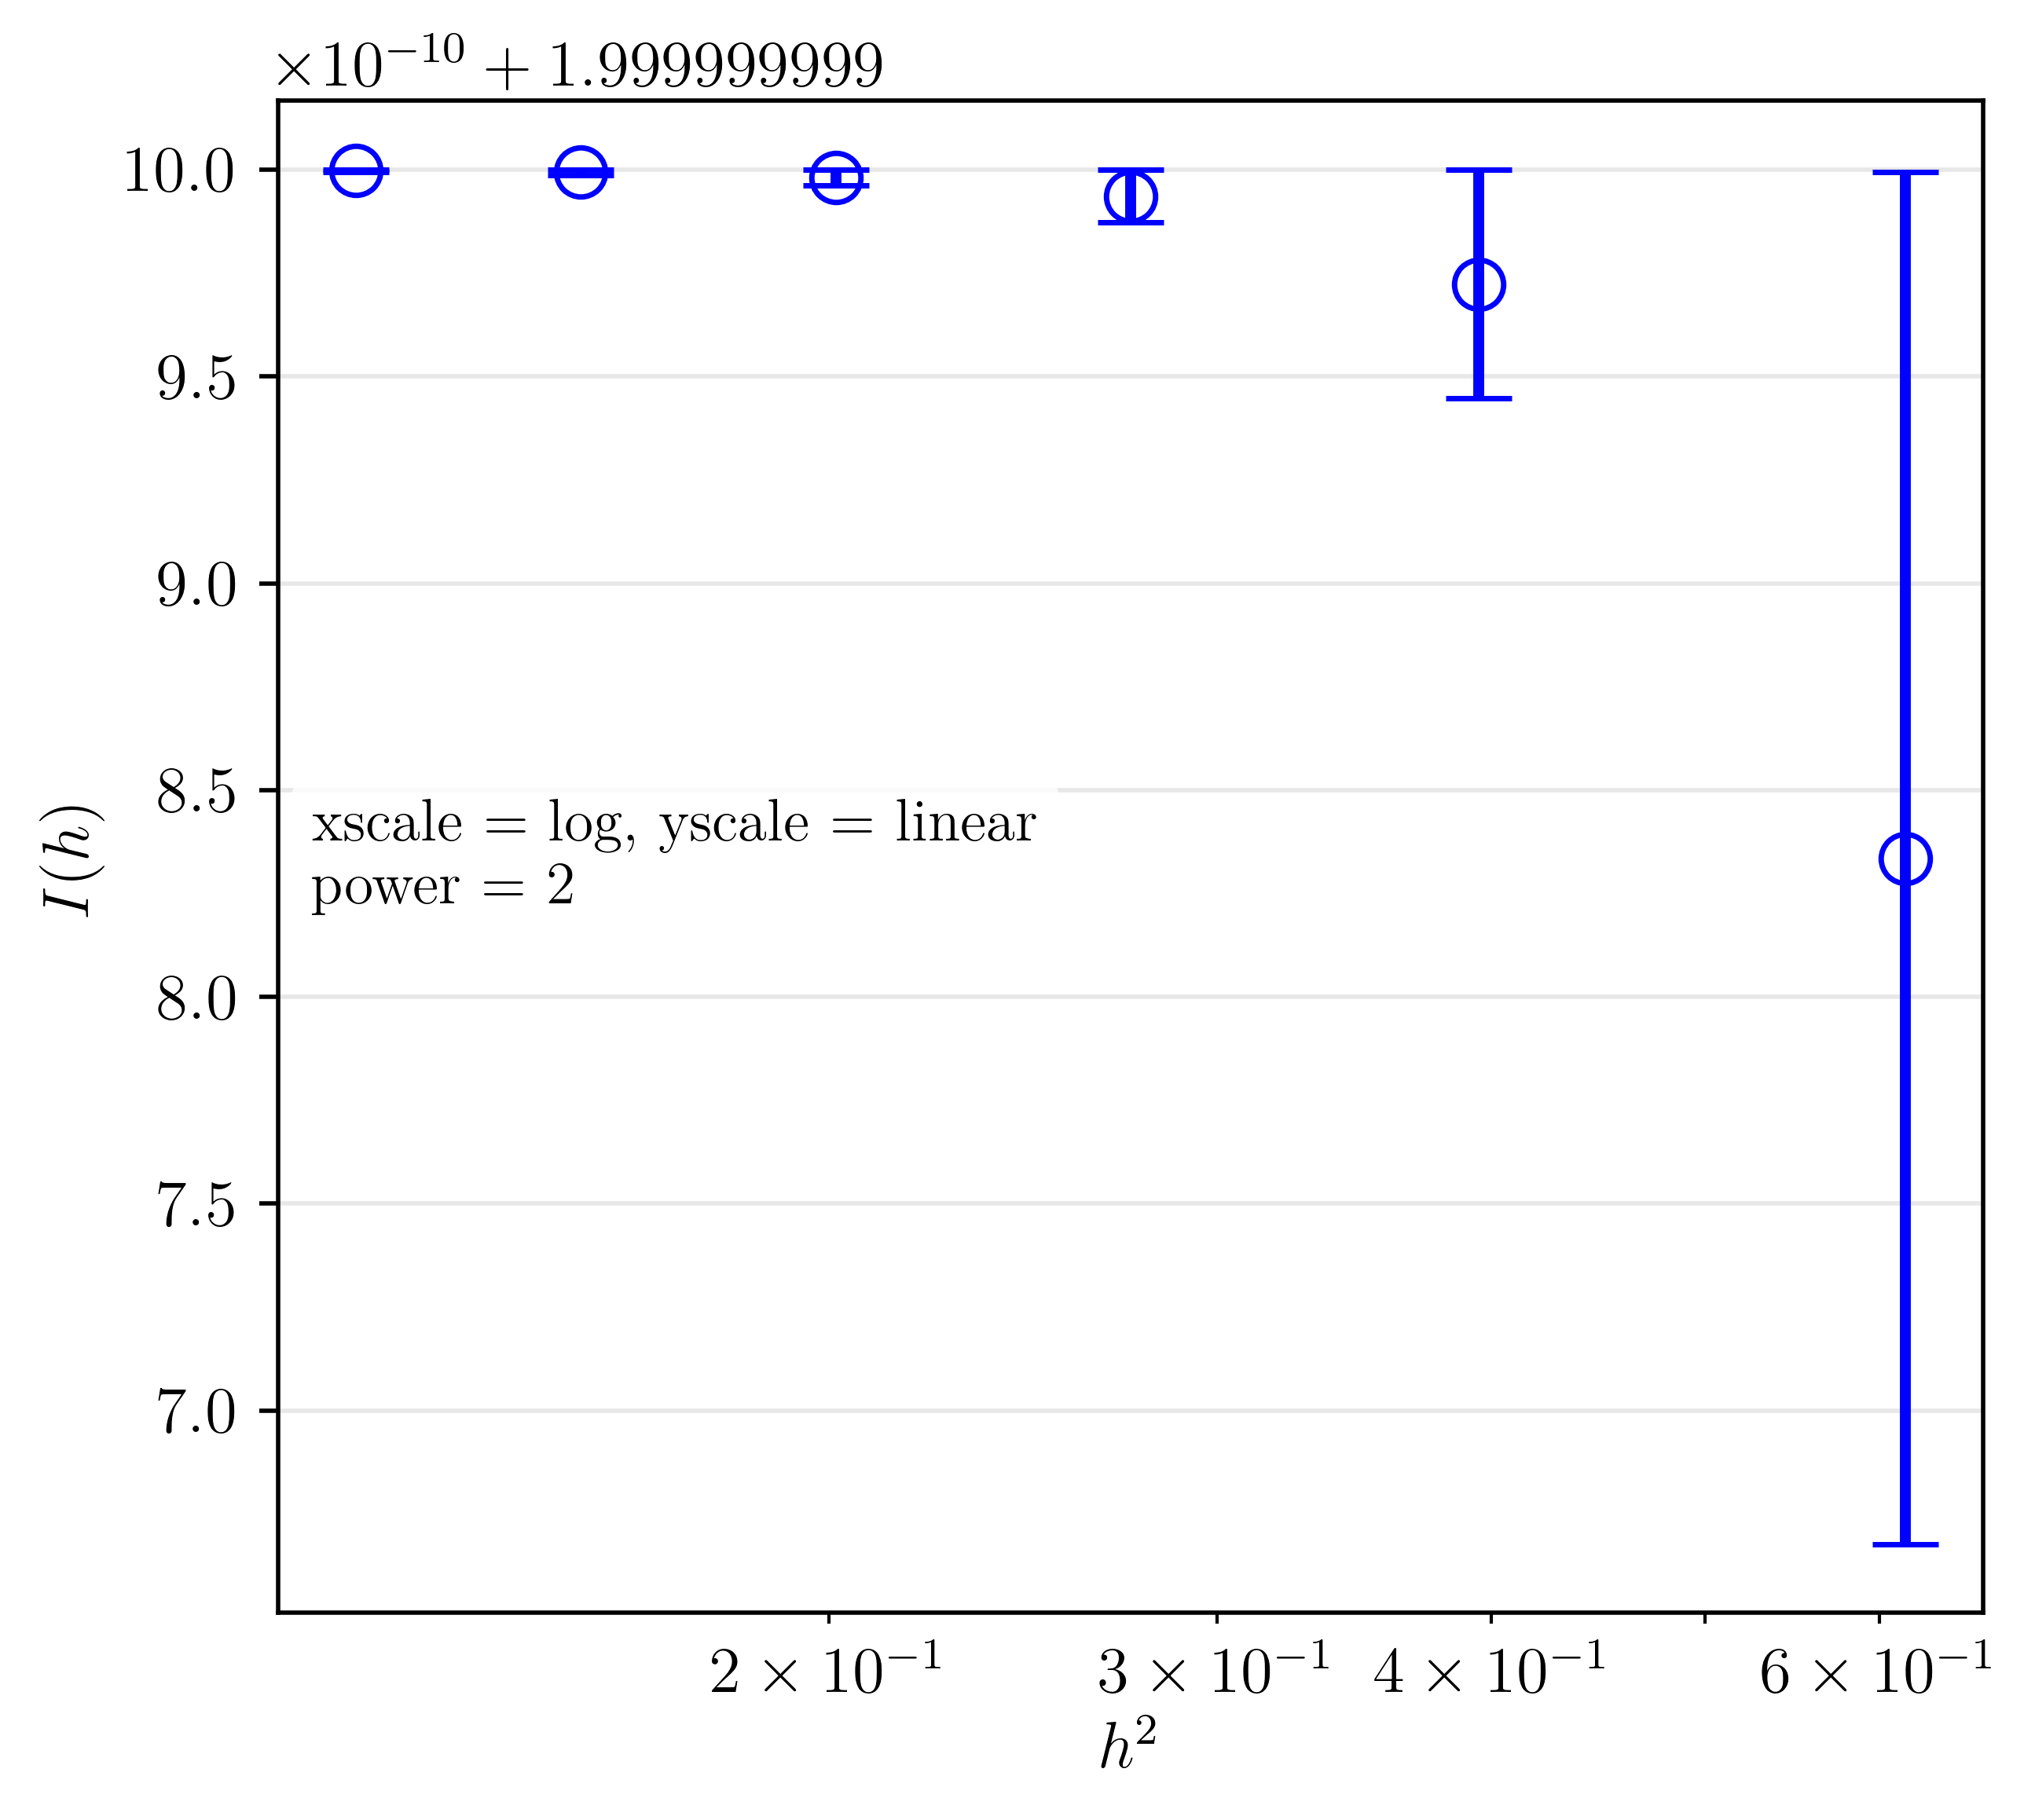

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_datapoints_hpow_2_log_linear-crop.pdf'.


In [6]:
plot_datapoints_result(
    run_result_filtered;
    name = run_result_filtered_file,
    h_power = 2,
    xscale = :log,
    yscale = :linear,
    figs_dir = save_path,
    save_file = true
)

## Export a datapoints summary table

Once the filtered datapoints have been inspected visually,
it is often useful to export them in a structured tabular form.

This summary captures:

- the retained step sizes
- the transformed horizontal coordinate (e.g., ``h^p``)
- the corresponding quadrature estimates
- pointwise uncertainty values
- plotting metadata such as axis-scale conventions

Such tables are convenient for documentation, sharing with
collaborators, or including in research notes.

In [7]:
write_convergence_summary_datapoints(
    run_result_filtered;
    name = run_result_filtered_file,
    h_power = 2,
    xscale = :log,
    yscale = :linear,
    out_dir = save_path,
    format = :md,
    save_file = true,
)

"# Convergence datapoints summary: ../samples/jld2/result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered.jld2\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Plot setup |\n|:--|:--|:--|\n| `(0.0, 3.14159265358979323846264338327950588)` | `gauss_p4 (LU_EXEX)` | `h^2, log/" ⋯ 190 bytes ⋯ " | `3.947842e-01` | 1.999999999972(28) |\n| `5.235988e-01` | `2.741557e-01` | 1.9999999999936(64) |\n| `4.487990e-01` | `2.014205e-01` | 1.9999999999981(19) |\n| `3.926991e-01` | `1.542126e-01` | 1.99999999999936(64) |\n| `3.490659e-01` | `1.218470e-01` | 1.99999999999975(25) |\n"

## Generate a datapoints-only internal note

Beyond a simple table, Reporter can construct a complete
self-contained LaTeX project describing the filtered dataset.

This internal note includes:

- a REVTeX-based master document
- the formatted datapoints summary table
- figure inclusion files
- the saved datapoints plot
- a reproducible Makefile
- optional automatic PDF compilation

The resulting directory can be archived or shared as a
stand-alone record of the filtered dataset prior to fitting.

In [8]:
note_info = write_convergence_internal_note_datapoints(
    run_result_filtered;
    name = run_result_filtered_file,
    h_power = 2,
    xscale = :log,
    yscale = :linear,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode

(./inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss
_p4_LU_EXEX_hpow_2_log_linear.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/

(note_dir = "../samples/jld2/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear", figs_dir = "../samples/jld2/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear/figs", summary_tex_path = "../samples/jld2/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear/summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear_table.tex", fig_tex_path = "../samples/jld2/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear/summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear_figs.tex", master_tex_path = "../samples/jld2/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p4_LU_EXEX_hpow_2_log_linear/inote_summary_result_sample_1d_gauss_p4_LU_EXEX_N_4_5_6_7_8_9_filtered_gauss_p

## Proceed to refitting

After verifying and archiving the filtered datapoints,
we can now perform the continuum extrapolation again.

Refitting the filtered dataset allows us to assess:

- how sensitive the extrapolated result is to removed points
- whether the retained resolution range improves stability
- how uncertainties change after filtering
- whether the original fit was influenced by outliers

### Tag outputs for Lesson 4

To avoid overwriting files generated in previous lessons,
we append a lesson-specific suffix to the result name.

This modified identifier will be used by downstream functions
(such as plotting or report generation) when constructing
output filenames.

In [9]:
result_string = "lesson4_" * result_string

"lesson4_sample_1d"

## Refit the filtered dataset

Now we perform the continuum extrapolation again using the
filtered dataset.

This allows us to compare how the fit changes after removing
selected resolution points from the original data.

In [10]:
fit_nterms = 4
fit_nerr_terms = 3

fit_result_filtered = least_chi_square_fit(
    run_result_filtered;
    fit_func_terms=fit_nterms, 
    ff_shift=0, 
    nerr_terms=fit_nerr_terms,
)

print_fit_result(fit_result_filtered)

[2026-03-21 20:04:10.889] axiswise residual ks = [[8, 10, 12]], merged ks = [8, 10, 12], fit powers (h^p), ff_shift=0 = [8, 10, 12]
[2026-03-21 20:04:15.735]            λ_0 = 2.00000000000000(42)
[2026-03-21 20:04:15.735]            λ_1 = -0.0000000011(33) *
[2026-03-21 20:04:15.735]            λ_2 = -0.000000000(18) *
[2026-03-21 20:04:15.735]            λ_3 = -0.000000000(21) *
[2026-03-21 20:04:15.735] 
[2026-03-21 20:04:15.735] Chi^2 / d.o.f. = 5.010644086669e-13 / 2 = 2.505322043334e-13
[2026-03-21 20:04:15.735] Result (h→0)   = 2.00000000000000(42)
[2026-03-21 20:04:15.735] 


## Visualize convergence after filtering

Finally we plot the convergence behaviour of the filtered dataset
together with the extrapolated continuum result.

This makes it easier to assess whether removing the selected
datapoints improves, stabilizes, or significantly changes
the final fit.

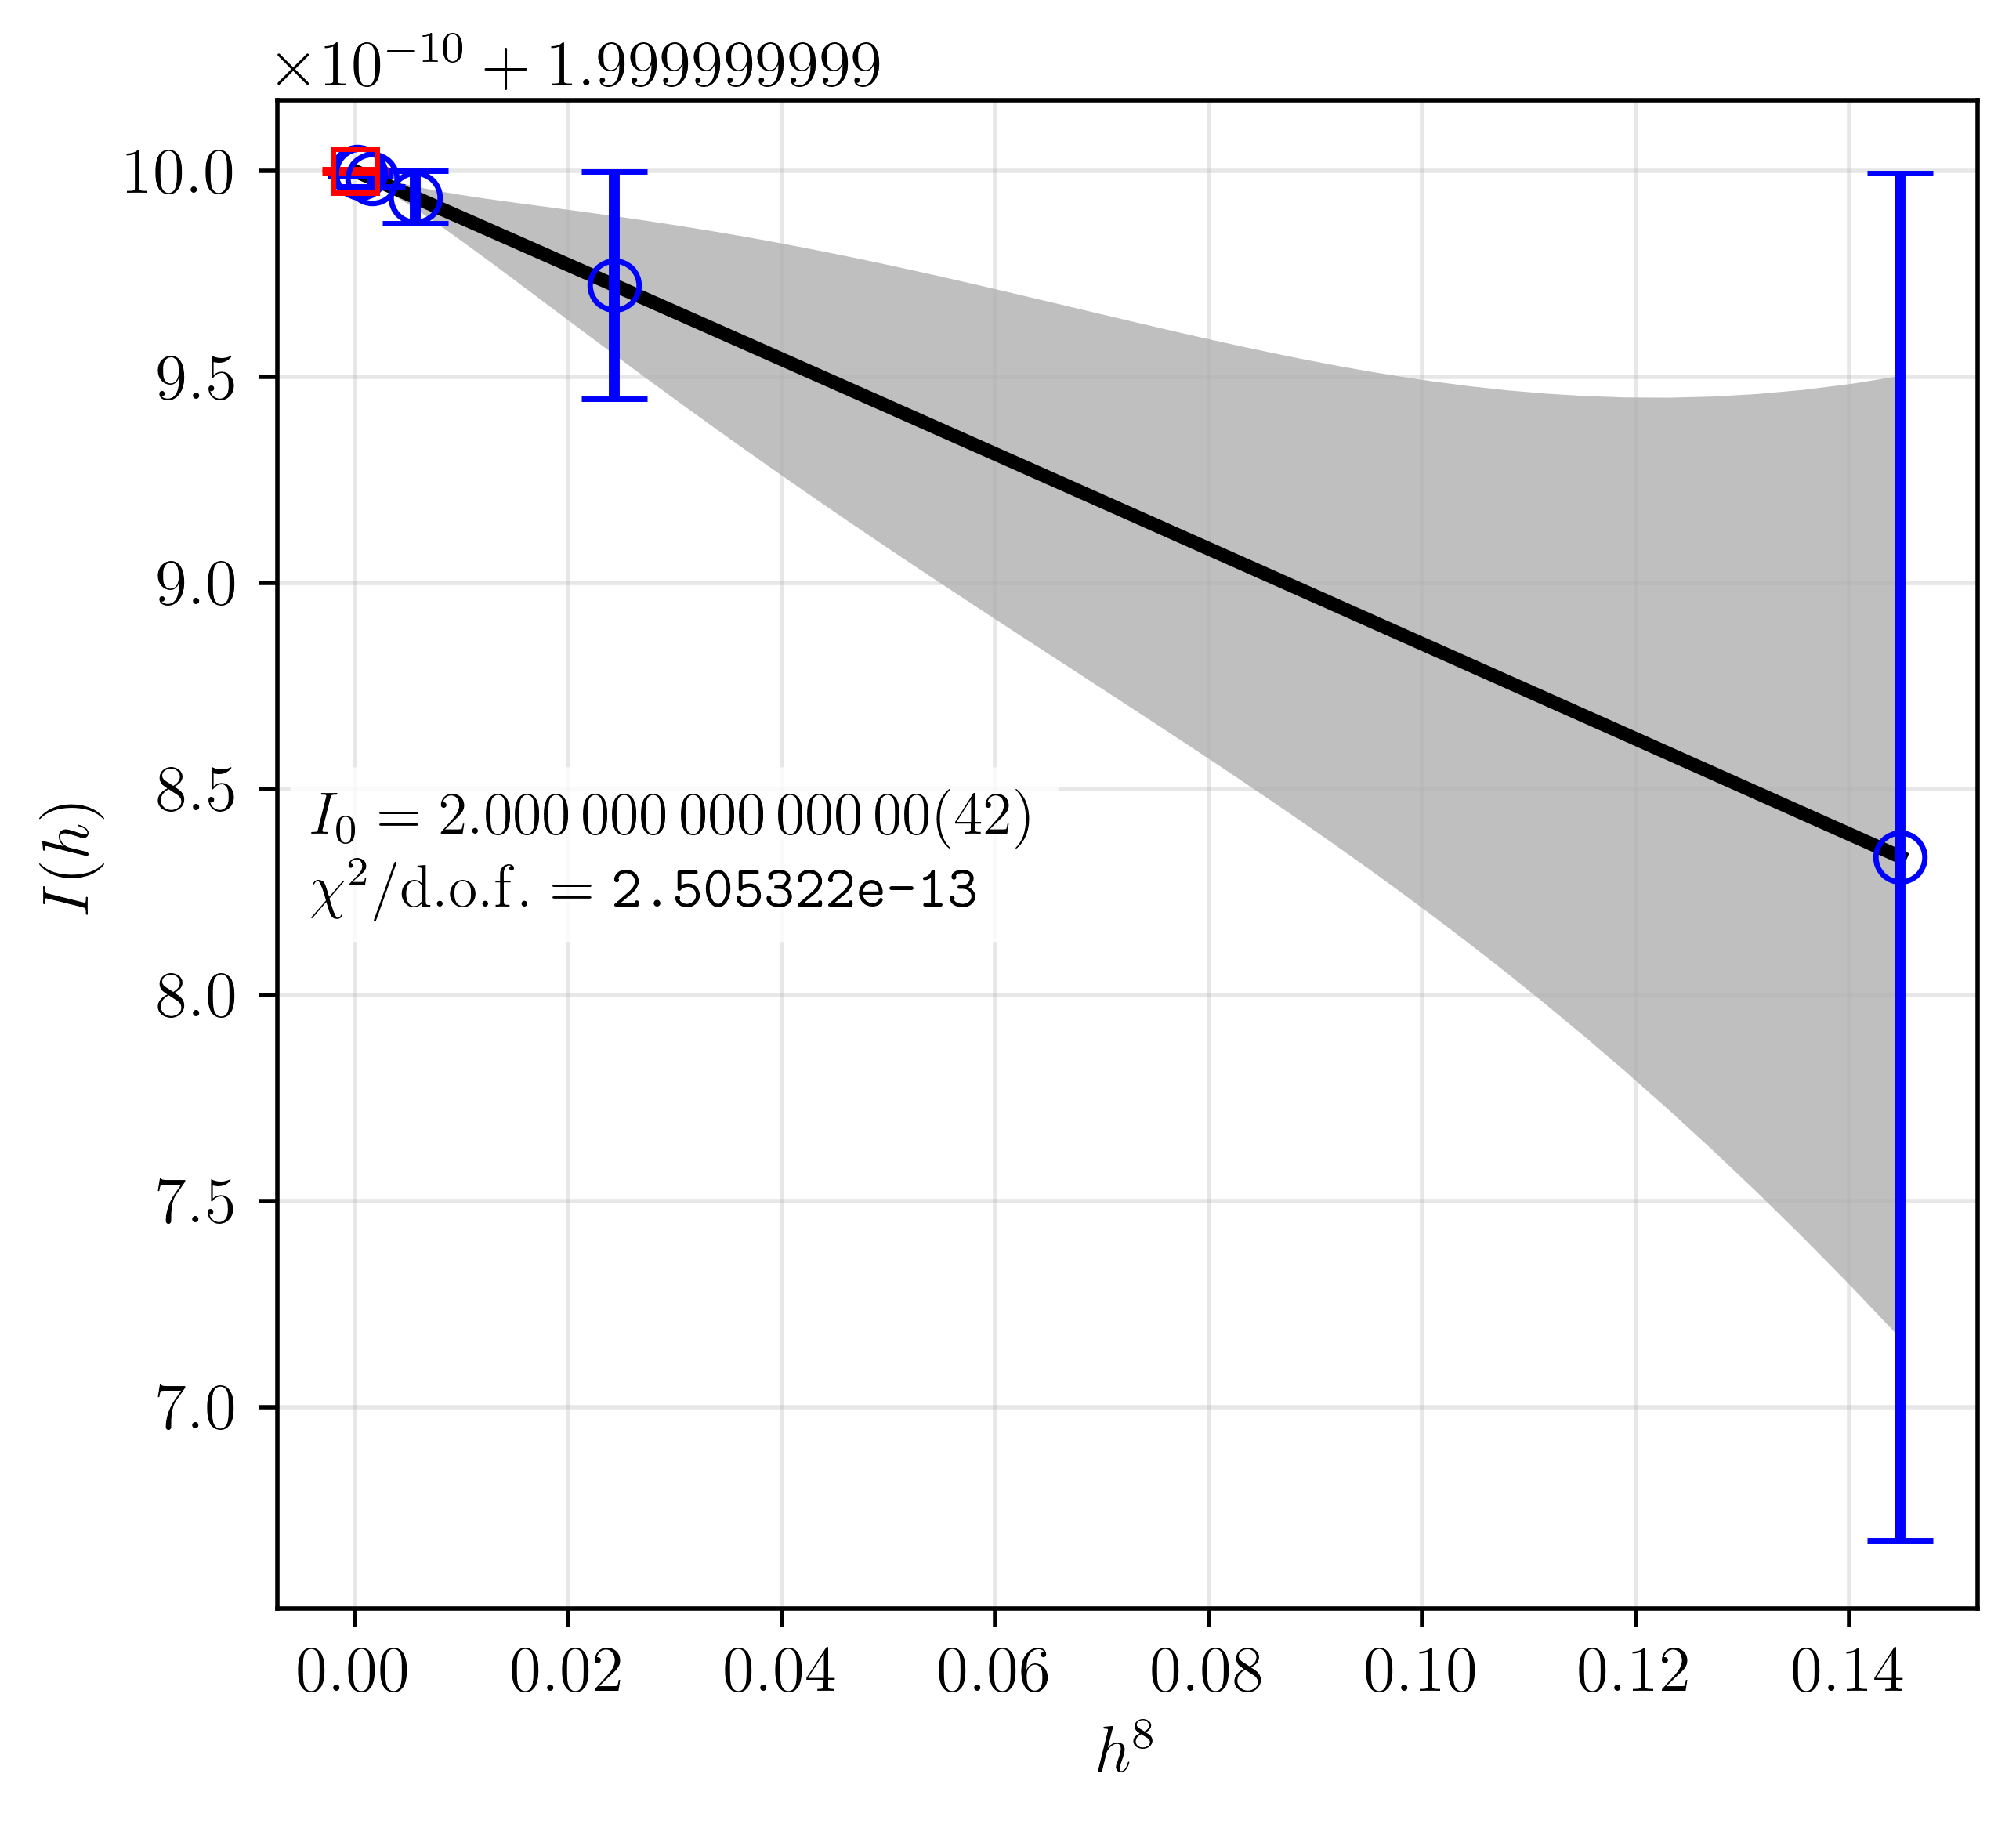

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson4_sample_1d_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson4_sample_1d_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


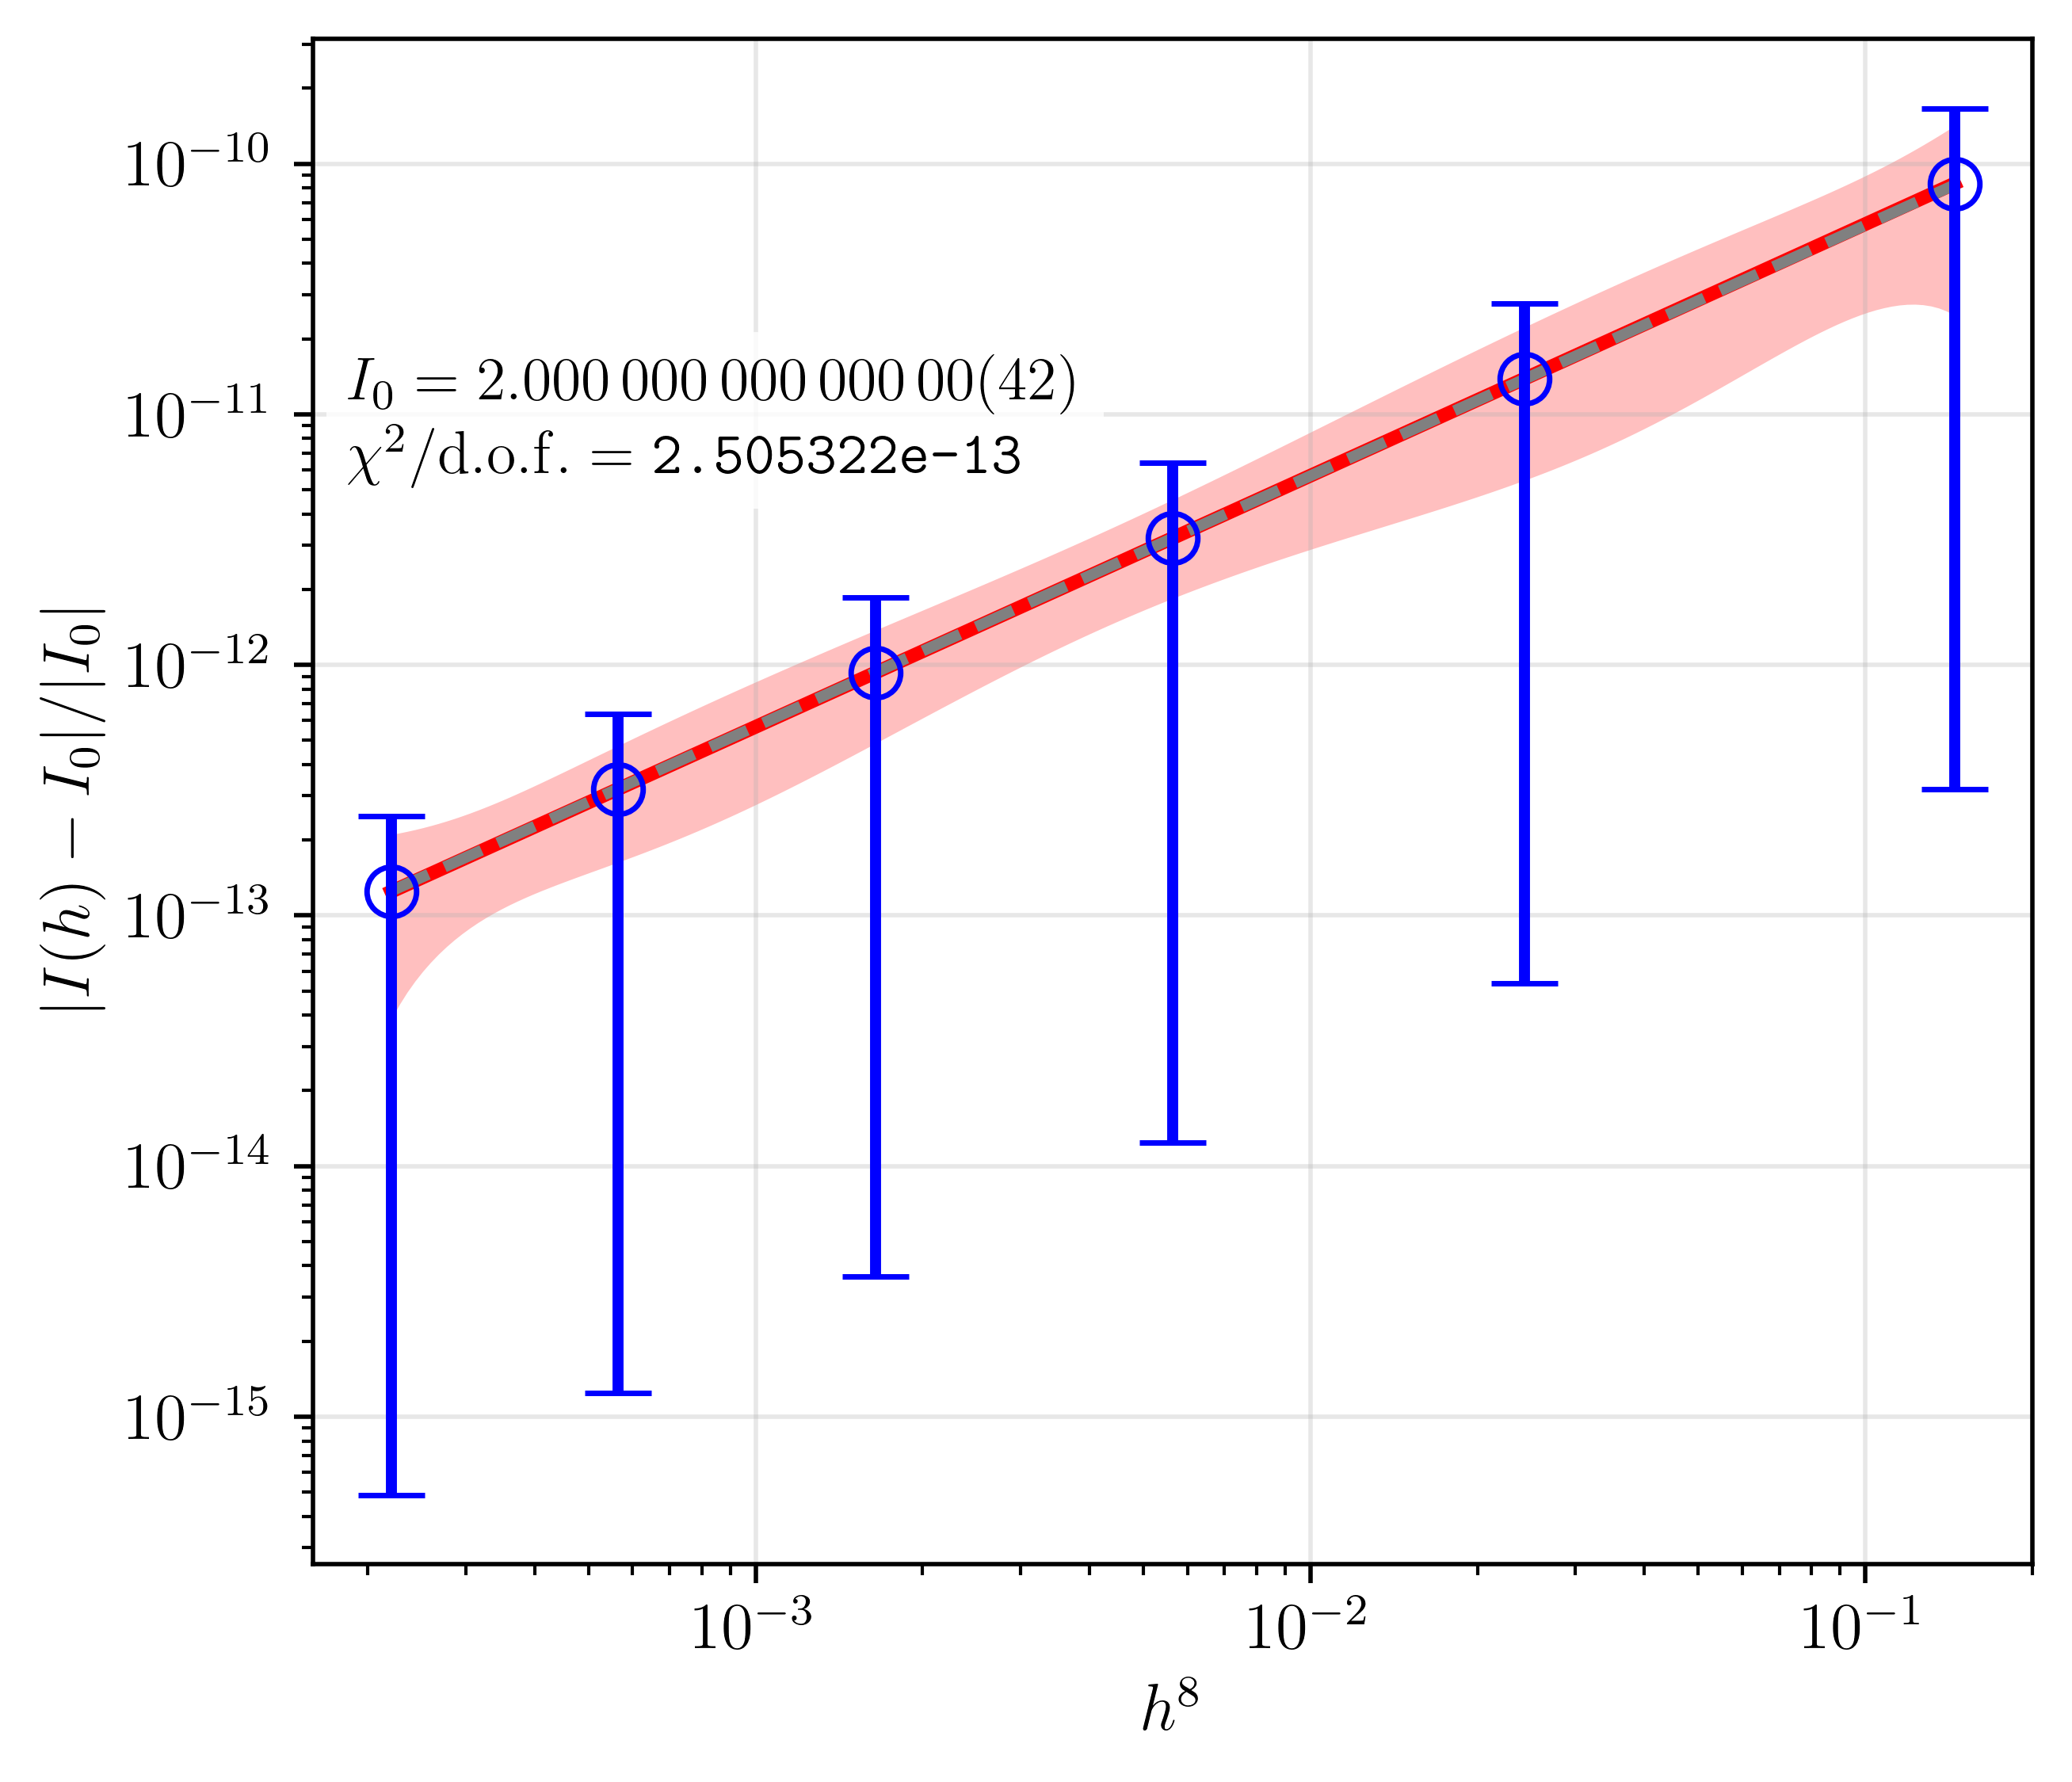

In [11]:
plot_convergence_result(
    run_result_filtered, 
    fit_result_filtered; 
    name=result_string,
    figs_dir=save_path,
    save_file=true
)

### Generate a convergence summary

We can produce a concise written summary of the fit results,
including the extrapolated value and diagnostic statistics.

This summary is saved in Markdown format and is useful for
quick inspection or inclusion in reports.

In [12]:
write_convergence_summary(
    run_result_filtered,
    fit_result_filtered;
    name = result_string,
    format = :md,
    out_dir = save_path,
    save_file = true,
)

"# Convergence summary: lesson4_sample_1d\n\n## Run configuration\n\n| Interval | Rule (Boundary) |\n|:--|:--|\n| `(0.0, 3.14159265358979323846264338327950588)` | `gauss_p4 (LU_EXEX)` |\n\n## Quadrature estimates and uncertainties for different step sizes\n\n| \$h\$ | \$h^8.0\$ | \$I(h)\$ |\n|:--|:" ⋯ 533 bytes ⋯ "mbda_2 h^{10.0} + \\lambda_3 h^{12.0}\n```\n\n| parameter | fit result |\n|:--|:--|\n| \$\\lambda_0\$ | **2.00000000000000(42)** |\n| \$\\lambda_1\$ | -0.0000000011(33) * |\n| \$\\lambda_2\$ | -0.000000000(18) * |\n| \$\\lambda_3\$ | -0.000000000(21) * |\n| \$\\chi^2 / \\text{d.o.f.}\$ | `2.505322e-13` |\n"

### Create an internal analysis note

For more detailed documentation, we can generate a full
internal note containing plots, tables, and metadata
describing the quadrature study.

If LaTeX is available, a PDF version will also be built
automatically.

In [13]:
note_info = write_convergence_internal_note(
    run_result_filtered,
    fit_result_filtered;
    name = result_string,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps12pt4-2.

(note_dir = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4", figs_dir = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/figs", summary_tex_path = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4_table.tex", fig_tex_path = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4_figs.tex", master_tex_path = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4.tex", makefile_path = "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/Makefile", moved_plots = ["../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/figs/result_lesson4_sample_1d_gauss_p4_LU_EXEX_extrap.pdf", "../samples/jld2/inote_summary_lesson4_sample_1d_gauss_p4_LU_EXEX_ff_4/figs/result_lesson4_sample_1d_gauss_p4_LU_EXEX_reldiff.pdf"], missi

## Summary

In this notebook we demonstrated how to rebuild a quadrature
dataset after selectively removing resolution points.

Workflow:

1. Generate or locate an existing result file
2. Exclude chosen `nsamples` using `drop_nsamples_from_file`
3. Load the filtered dataset
4. Inspect the remaining datapoints
5. Generate summaries and internal reports for the filtered data
6. Perform continuum extrapolation and convergence analysis again

This workflow is particularly useful for robustness studies,
allowing one to assess how sensitive the extrapolated result
is to specific resolutions or potential outliers.

Typical use cases include:

- testing fit stability under data removal,
- studying the influence of coarse or fine resolutions,
- diagnosing anomalous datapoints,
- documenting intermediate or exploratory datasets,
- producing reproducible reports prior to final analysis.

By enabling controlled data pruning, this approach helps ensure
that final conclusions are not dominated by a small subset of
resolutions and supports transparent, defensible analysis.